In [12]:
import numpy as np
import pandas as pd
import pywt

def wavelet_denoise(data, wavelet='db4', level=2):
    """
    Applies Discrete Wavelet Transform (DWT) to remove high-frequency noise from Stock data.
    """
    coeffs = pywt.wavedec(data, wavelet, mode='per', level=level)

    detail_coeffs = coeffs[-1]
    # Calculate threshold based on noise standard deviation
    sigma = (1 / 0.6745) * np.median(np.abs(detail_coeffs - np.median(detail_coeffs)))
    threshold = sigma * np.sqrt(2 * np.log(len(data)))

    denoised_coeffs = [coeffs[0]] + [pywt.threshold(c, value=threshold, mode='soft') for c in coeffs[1:]]

    reconstructed_signal = pywt.waverec(denoised_coeffs, wavelet, mode='per')

    return reconstructed_signal[:len(data)]

def main():
    input_filepath = '/content/VZ_final_DF.csv'
    output_filepath = 'denoised_VZ_stock_data.csv'

    columns_to_denoise = [
        'Price',
        'Volume',
        'Relative Volume_20',
        'Relative Volume_50',
        '20-Day Average Swing'
    ]

    # --- Load Data ---
    print("Loading data from {}.".format(input_filepath))
    try:
        df = pd.read_csv(input_filepath)
        df = df[columns_to_denoise].copy()


    except FileNotFoundError:
        print("File not found. Please check the file path.")
        return

    # --- Apply Filter ---
    print("Applying wavelet transform noise filtering...")
    for col in columns_to_denoise:
        # Overwrite the existing column with the denoised data
        df[col] = wavelet_denoise(df[col].values, wavelet='db4', level=2)

        # Rename the column header
        new_name = 'denoised_{}'.format(col)
        df.rename(columns={col: new_name}, inplace=True)

        print("Processed and renamed: {} -> {}".format(col, new_name))

    # --- Save Data ---
    print("Saving updated dataset to {}.".format(output_filepath))
    df.to_csv(output_filepath, index=False)
    print("Data preprocessing complete!")

if __name__ == "__main__":
    main()

Loading data from /content/VZ_final_DF.csv.
Applying wavelet transform noise filtering...
Processed and renamed: Price -> denoised_Price
Processed and renamed: Volume -> denoised_Volume
Processed and renamed: Relative Volume_20 -> denoised_Relative Volume_20
Processed and renamed: Relative Volume_50 -> denoised_Relative Volume_50
Processed and renamed: 20-Day Average Swing -> denoised_20-Day Average Swing
Saving updated dataset to denoised_VZ_stock_data.csv.
Data preprocessing complete!


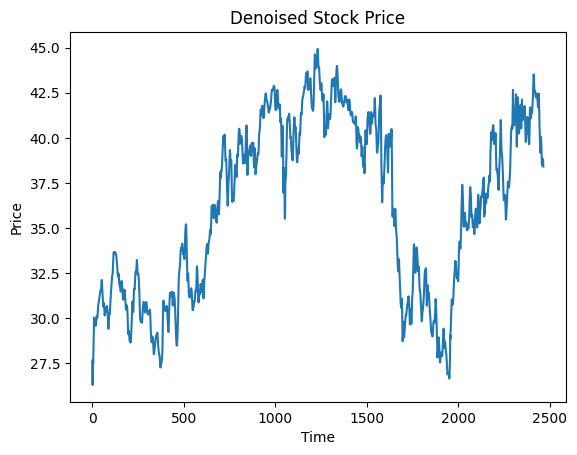

In [13]:
ddf=pd.read_csv('/content/denoised_VZ_stock_data.csv')
ndf=pd.read_csv('/content/VZ_final_DF.csv')

import matplotlib.pyplot as plt

plt.plot(ddf['denoised_Price'], label='Denoised Price')
# plt.plot(ndf['Price'], label='Original Price')

plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Denoised Stock Price')
# plt.legend()
plt.show()

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

class StockRollingWindowDataset(Dataset):
    def __init__(self, dataframe, target_column, max_window_size=60):
        """
        Args:
            dataframe (pd.DataFrame): preprocessed, denoised dataframe.
            target_column (str): Denoised price
            max_window_size (int): window size
        """
        self.features = dataframe.drop(columns=['Date'], errors='ignore').values.astype(np.float32)

        self.targets = dataframe[target_column].shift(-1).values.astype(np.float32)

        self.max_window_size = max_window_size

        self.valid_indices = range(self.max_window_size, len(self.features) - 1)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        end_idx = self.valid_indices[idx]
        start_idx = end_idx - self.max_window_size

        x = self.features[start_idx:end_idx]
        y = self.targets[end_idx]

        return torch.tensor(x), torch.tensor(y).unsqueeze(-1)

In [15]:
import torch.nn as nn
import torch.nn.functional as F

class AdaptiveTimeWindow(nn.Module):
    def __init__(self, num_features, max_window_size):
        super(AdaptiveTimeWindow, self).__init__()
        self.max_window_size = max_window_size

        self.temporal_gating = nn.Sequential(
            nn.Linear(num_features, 16),
            nn.ReLU(),
            # Output a single score per time step
            nn.Linear(16, 1)
        )

    def forward(self, x):
        """
        x shape: (batch_size, sequence_length, num_features)
        """
        raw_gate_scores = self.temporal_gating(x)
        time_weights = F.softmax(raw_gate_scores, dim=1)
        adaptively_weighted_x = x * time_weights

        return adaptively_weighted_x, time_weights

In [16]:
#3
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvEnhancedSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        """
        Args:
            embed_dim (int): The number of features/channels in input data.
            num_heads (int): Number of attention heads
        """
        super(ConvEnhancedSelfAttention, self).__init__()
        self.embed_dim = embed_dim

        self.self_attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)

        # 2. Convolutional network to learn the weighting factor W_t
        self.conv_weighting = nn.Sequential(
            nn.Conv1d(in_channels=embed_dim, out_channels=embed_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=embed_dim, out_channels=embed_dim, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        """
        x shape: (batch_size, sequence_length, embed_dim)
        """
        # Calculate Standard Attention
        attn_output, attn_weights = self.self_attention(x, x, x)

        # Calculate Convolutional Weights (W_t)
        # sequence in the last dimension
        x_transposed = x.transpose(1, 2)

        # Pass the original features through the CNN to learn the dynamic weights
        w_t_transposed = self.conv_weighting(x_transposed)

        # Transpose back to match the attention output shape
        w_t = w_t_transposed.transpose(1, 2)

        # Calculate S_match, Element wise multiplication
        s_match = w_t * attn_output

        return s_match, attn_weights, w_t

In [17]:
#4
import torch
import torch.nn as nn

class ImprovedTransformer(nn.Module):
    def __init__(self, num_features, max_window_size, num_heads):
        super(ImprovedTransformer, self).__init__()

        self.adaptive_window = AdaptiveTimeWindow(num_features, max_window_size)

        self.conv_attention = ConvEnhancedSelfAttention(embed_dim=num_features, num_heads=num_heads)

        # The MLP to map the attention output to a single price prediction
        self.mlp = nn.Sequential(
            nn.Linear(num_features * max_window_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # Apply Adaptive Time Window
        adaptively_weighted_x, _ = self.adaptive_window(x)

        # Apply Convolution-Enhanced Attention
        s_match, _, _ = self.conv_attention(adaptively_weighted_x)

        # Flatten the output for the MLP
        flat_out = s_match.reshape(s_match.shape[0], -1)

        # Final Prediction
        y_pred = self.mlp(flat_out)

        return y_pred, s_match

In [18]:
class HybridLoss(nn.Module):
    def __init__(self, lambda1=1.0, lambda2=0.02):
        """
        lambda1: Weight for the prediction error (MSE).
        lambda2: Weight for the attention regularization. Keep this small initially.
        """
        super(HybridLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.lambda1 = lambda1
        self.lambda2 = lambda2

    def forward(self, y_pred, y_true, s_match):
        # 1. Standard prediction error
        mse_loss = self.mse(y_pred, y_true)

        # 2. Attention regularization (L1 sparsity on the matching scores)
        # This penalizes the model for paying attention to too many things at once
        attention_loss = torch.mean(torch.abs(s_match))

        # 3. Combined Loss
        total_loss = (self.lambda1 * mse_loss) + (self.lambda2 * attention_loss)

        return total_loss, mse_loss, attention_loss

In [19]:
import torch.optim as optim

def train_model(model, dataloader, epochs=50, learning_rate=0.001, lambda1=1.0, lambda2=0.02):
    # Initialize our custom loss and a standard Adam optimizer
    criterion = HybridLoss(lambda1=lambda1, lambda2=lambda2)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.train()

    for epoch in range(epochs):
        epoch_total_loss = 0.0
        epoch_mse_loss = 0.0

        for batch_x, batch_y in dataloader:
            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            y_pred, s_match = model(batch_x)

            # Calculate Hybrid Loss
            total_loss, mse_loss, attn_loss = criterion(y_pred, batch_y, s_match)

            # Backward pass and optimization
            total_loss.backward()
            optimizer.step()

            # Track metrics
            epoch_total_loss += total_loss.item()
            epoch_mse_loss += mse_loss.item()

        # Print progress
        avg_loss = epoch_total_loss / len(dataloader)
        avg_mse = epoch_mse_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{epochs} | Total Loss: {avg_loss:.4f} | MSE: {avg_mse:.4f}")



Loading data from denoised_VZ_stock_data.csv...
Epoch 1/30 | Total Loss: 0.3540 | MSE: 0.3538
Epoch 2/30 | Total Loss: 0.1248 | MSE: 0.1247
Epoch 3/30 | Total Loss: 0.1160 | MSE: 0.1158
Epoch 4/30 | Total Loss: 0.1099 | MSE: 0.1098
Epoch 5/30 | Total Loss: 0.1099 | MSE: 0.1097
Epoch 6/30 | Total Loss: 0.1152 | MSE: 0.1150
Epoch 7/30 | Total Loss: 0.0992 | MSE: 0.0990
Epoch 8/30 | Total Loss: 0.1108 | MSE: 0.1106
Epoch 9/30 | Total Loss: 0.0917 | MSE: 0.0915
Epoch 10/30 | Total Loss: 0.0958 | MSE: 0.0956
Epoch 11/30 | Total Loss: 0.0927 | MSE: 0.0925
Epoch 12/30 | Total Loss: 0.0879 | MSE: 0.0877
Epoch 13/30 | Total Loss: 0.0852 | MSE: 0.0850
Epoch 14/30 | Total Loss: 0.0917 | MSE: 0.0915
Epoch 15/30 | Total Loss: 0.0739 | MSE: 0.0737
Epoch 16/30 | Total Loss: 0.0778 | MSE: 0.0776
Epoch 17/30 | Total Loss: 0.0747 | MSE: 0.0745
Epoch 18/30 | Total Loss: 0.0743 | MSE: 0.0741
Epoch 19/30 | Total Loss: 0.0761 | MSE: 0.0759
Epoch 20/30 | Total Loss: 0.0715 | MSE: 0.0713
Epoch 21/30 | Total L

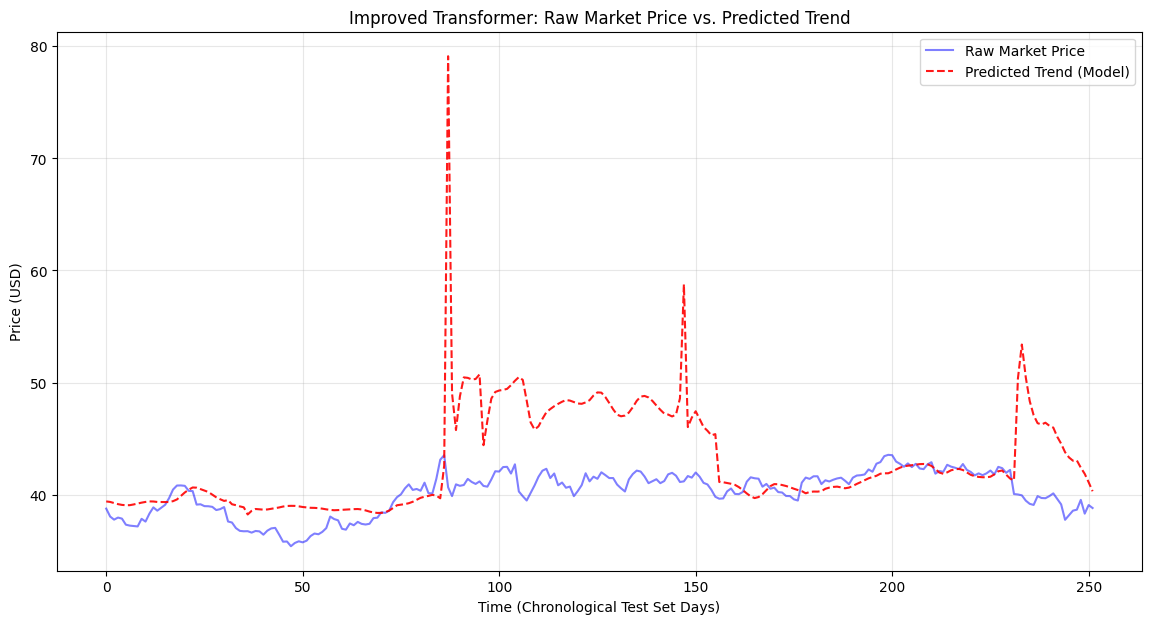

In [21]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler

# Setup, Load, and Scale Data
filepath = 'denoised_VZ_stock_data.csv' # Corrected filename
print("Loading data from {}...".format(filepath))
df_denoised = pd.read_csv(filepath)

TARGET_COLUMN = 'denoised_Price'
MAX_WINDOW_SIZE = 60

# drop 'Date'
if 'Date' in df_denoised.columns:
    df_features = df_denoised.drop(columns=['Date'])
else:
    df_features = df_denoised.copy()

NUM_FEATURES = len(df_features.columns)

# scale data
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

# Fit/Transform features
scaled_features = feature_scaler.fit_transform(df_features)

# Fit/Transform the target column so we can un-scale it later
target_idx = df_features.columns.get_loc(TARGET_COLUMN)
scaled_targets = target_scaler.fit_transform(df_features.iloc[:, target_idx].values.reshape(-1, 1))

# scale data
df_scaled = pd.DataFrame(scaled_features, columns=df_features.columns)
df_scaled[TARGET_COLUMN] = scaled_targets

# Create Dataset
dataset = StockRollingWindowDataset(df_scaled, target_column=TARGET_COLUMN, max_window_size=MAX_WINDOW_SIZE)

train_size = int(len(dataset)-252)
test_size = len(dataset) - train_size

train_dataset = Subset(dataset, range(0, train_size))
test_dataset = Subset(dataset, range(train_size, len(dataset)))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Initialize Model
model = ImprovedTransformer(num_features=NUM_FEATURES, max_window_size=MAX_WINDOW_SIZE, num_heads=1)

# Train
# print("Starting Training...")
# # We can bump epochs up slightly now that the data is scaled
train_model(model, train_loader, epochs=30, learning_rate=0.01)

# model = ImprovedTransformer(num_features=NUM_FEATURES, max_window_size=MAX_WINDOW_SIZE, num_heads=1)
# model.load_state_dict(torch.load('/content/tuned_transformer_weights_with55profit.pth'))
model.eval() #PREDICT

# Evaluate and Predict
print("Generating Predictions...")
model.eval()

all_predictions = []
all_true_values = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        y_pred, _ = model(batch_x)
        all_predictions.extend(y_pred.cpu().numpy().flatten())
        all_true_values.extend(batch_y.cpu().numpy().flatten())

all_predictions_unscaled = target_scaler.inverse_transform(np.array(all_predictions).reshape(-1, 1))
all_true_values_unscaled = target_scaler.inverse_transform(np.array(all_true_values).reshape(-1, 1))

# Plot Results against RAW Data
print("Loading original raw data for plotting...")
df_raw = pd.read_csv('/content/VZ_final_DF.csv')

start_of_test_set = MAX_WINDOW_SIZE + train_size
test_indices = range(start_of_test_set, start_of_test_set + len(all_predictions_unscaled))

raw_actual_prices = df_raw['Price'].iloc[test_indices].values

plt.figure(figsize=(14, 7))
plt.plot(raw_actual_prices, label='Raw Market Price', color='blue', alpha=0.5)

plt.plot(all_predictions_unscaled, label='Predicted Trend (Model)', color='red', alpha=0.9, linestyle='--')

plt.title('Improved Transformer: Raw Market Price vs. Predicted Trend')
plt.xlabel('Time (Chronological Test Set Days)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
print("Test Size: {}".format(test_size))
print("Train Size: {}".format(train_size))

Test Size: 252
Train Size: 2152


In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Test Metrics")

# Scaled Metrics
scaled_mse = mean_squared_error(all_true_values, all_predictions)
scaled_rmse = np.sqrt(scaled_mse)
scaled_mae = mean_absolute_error(all_true_values, all_predictions)

print("Scaled MSE:  {:.4f}".format(scaled_mse))
print("Scaled RMSE: {:.4f}".format(scaled_rmse))
print("Scaled MAE:  {:.4f}".format(scaled_mae))

# Unscaled Metrics
unscaled_mse = mean_squared_error(all_true_values_unscaled, all_predictions_unscaled)
unscaled_rmse = np.sqrt(unscaled_mse)
unscaled_mae = mean_absolute_error(all_true_values_unscaled, all_predictions_unscaled)

print("\nReal-World (Dollar) Metrics:")
print("Unscaled MSE:  ${:.4f}".format(unscaled_mse))
print("Unscaled RMSE: ${:.2f}".format(unscaled_rmse))
print("Unscaled MAE:  ${:.2f}".format(unscaled_mae))

Test Metrics
Scaled MSE:  1.0634
Scaled RMSE: 1.0312
Scaled MAE:  0.6700

Real-World (Dollar) Metrics:
Unscaled MSE:  $25.0178
Unscaled RMSE: $5.00
Unscaled MAE:  $3.25


In [24]:
# Save the model's learned parameters
torch.save(model.state_dict(), 'tuned_transformer_weights.pth')



In [25]:
# @title
!pip install torchviz
from torchviz import make_dot

# Create a dummy input tensor with your specific shape (Batch, Window, Features)
dummy_input = torch.randn(1, 60, NUM_FEATURES)

# Pass it through the model
y_pred, s_match = model(dummy_input)

# Generate the visualization
make_dot(y_pred, params=dict(model.named_parameters())).render("model_architecture", format="png")

'model_architecture.png'

In [26]:
# @title
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Summary requires the input size (Features, Window)
summary(model, input_size=(60, NUM_FEATURES))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 60, 16]              96
              ReLU-2               [-1, 60, 16]               0
            Linear-3                [-1, 60, 1]              17
AdaptiveTimeWindow-4  [[-1, 60, 5], [-1, 60, 1]]               0
MultiheadAttention-5  [[-1, 60, 5], [-1, 60, 60]]               0
            Conv1d-6                [-1, 5, 60]              80
              ReLU-7                [-1, 5, 60]               0
            Conv1d-8                [-1, 5, 60]              30
           Sigmoid-9                [-1, 5, 60]               0
ConvEnhancedSelfAttention-10  [[-1, 60, 5], [-1, 60, 60], [-1, 60, 5]]               0
           Linear-11                   [-1, 64]          19,264
             ReLU-12                   [-1, 64]               0
          Dropout-13                   [-1, 64]               0
           Li

In [27]:
import pandas as pd
from IPython.display import display

# Initialize lists to store our trading log and track profit
trades = []
total_profit = 0.0

# Iterate through every prediction in the test set
for i in range(len(all_predictions_unscaled)):
    # Use 'i' to track the relative day in the test sequence (starting at Day 1)
    buy_day = i + 1
    sell_day = i + 2

    # The index in the raw dataframe for the 'next day' (target day)
    target_day_idx = test_indices[i]

    # The 'current day' (Day T) is the day before the target day (Day T+1)
    current_day_idx = target_day_idx - 1

    # Extract the exact prices
    current_actual_price = df_raw['Price'].iloc[current_day_idx]
    predicted_next_price = all_predictions_unscaled[i][0]
    actual_next_price = raw_actual_prices[i] # Equivalent to df_raw['Price'].iloc[target_day_idx]

    # Trading Logic: Buy a share if the model predicts the price will go up tomorrow
    if predicted_next_price > current_actual_price:
        # We simulate buying at the current day's close and selling at the next day's close
        profit_loss = actual_next_price - current_actual_price
        total_profit += profit_loss

        # Log the trade details with relative Test Days
        trades.append({
            'Buy Day': buy_day,
            'Sell Day': sell_day,
            'Buy Price': f"${current_actual_price:.2f}",
            'Predicted Sell': f"${predicted_next_price:.2f}",
            'Actual Sell': f"${actual_next_price:.2f}",
            'Profit/Loss': f"${profit_loss:.2f}",
            'Cumulative Profit': f"${total_profit:.2f}"
        })

# Convert the trade log into a pandas DataFrame for a clean table format
if trades:
    trades_df = pd.DataFrame(trades)

    # Calculate some quick statistics
    winning_trades = len(trades_df[trades_df['Profit/Loss'].str.contains('-') == False])
    losing_trades = len(trades_df) - winning_trades
    win_rate = (winning_trades / len(trades_df)) * 100

    print("### Trading Bot Simulation Results ###")
    print(f"Total Trades Executed: {len(trades_df)}")
    print(f"Winning Trades:        {winning_trades}")
    print(f"Losing Trades:         {losing_trades}")
    print(f"Win Rate:              {win_rate:.1f}%")
    print("-" * 38)
    print(f"FINAL PROFIT/LOSS:     ${total_profit:.2f}\n")

    print("Detailed Trade Log:")
    display(trades_df)
else:
    print("No trades were executed. The model never predicted an upward trend in the test set.")

### Trading Bot Simulation Results ###
Total Trades Executed: 179
Winning Trades:        86
Losing Trades:         93
Win Rate:              48.0%
--------------------------------------
FINAL PROFIT/LOSS:     $-1.40

Detailed Trade Log:


,Buy Day,Sell Day,Buy Price,Predicted Sell,Actual Sell,Profit/Loss,Cumulative Profit
0,1,2,$37.96,$39.39,$38.74,$0.78,$0.78
1,2,3,$38.74,$39.34,$38.04,$-0.71,$0.07
2,3,4,$38.04,$39.24,$37.76,$-0.28,$-0.20
3,4,5,$37.76,$39.14,$37.94,$0.18,$-0.02
4,5,6,$37.94,$39.08,$37.85,$-0.09,$-0.11
...,...,...,...,...,...,...,...
174,248,249,$38.56,$43.04,$38.65,$0.09,$-1.55
175,249,250,$38.65,$42.40,$39.52,$0.87,$-0.67
176,250,251,$39.52,$41.85,$38.30,$-1.23,$-1.90
177,251,252,$38.30,$41.10,$39.06,$0.77,$-1.13


In [28]:
trades_df.to_csv("VZ_trades.csv", index=False)
# List of columns to clean before saving
columns_to_clean = ['Buy Price', 'Predicted Sell', 'Actual Sell', 'Profit/Loss', 'Cumulative Profit']

for col in columns_to_clean:
    # Check if the column exists and if its values are strings before trying to replace
    # This handles cases where the dataframe might be empty or columns are already numeric
    if col in trades_df.columns and trades_df[col].dtype == 'object':
        trades_df[col] = trades_df[col].astype(str).str.replace(r'[$,%]', '', regex=True).astype(float)

trades_df.to_csv("VZ_trades.csv", index=False)
trades_df.describe()

,Buy Day,Sell Day,Buy Price,Predicted Sell,Actual Sell,Profit/Loss,Cumulative Profit
count,179.00000,179.00000,179.000000,179.000000,179.000000,179.000000,179.000000
mean,110.22905,111.22905,39.535587,43.708715,39.527821,-0.008045,-1.343240
std,70.50865,70.50865,1.925859,5.188379,1.916735,0.555418,1.060736
min,1.00000,2.00000,35.390000,38.220000,35.390000,-2.860000,-3.620000
25%,50.50000,51.50000,37.875000,39.125000,37.875000,-0.285000,-2.020000
50%,108.00000,109.00000,39.860000,42.400000,39.850000,-0.020000,-1.400000
75%,152.50000,153.50000,41.145000,47.840000,41.120000,0.300000,-0.690000
max,252.00000,253.00000,43.510000,79.120000,42.780000,1.590000,1.720000


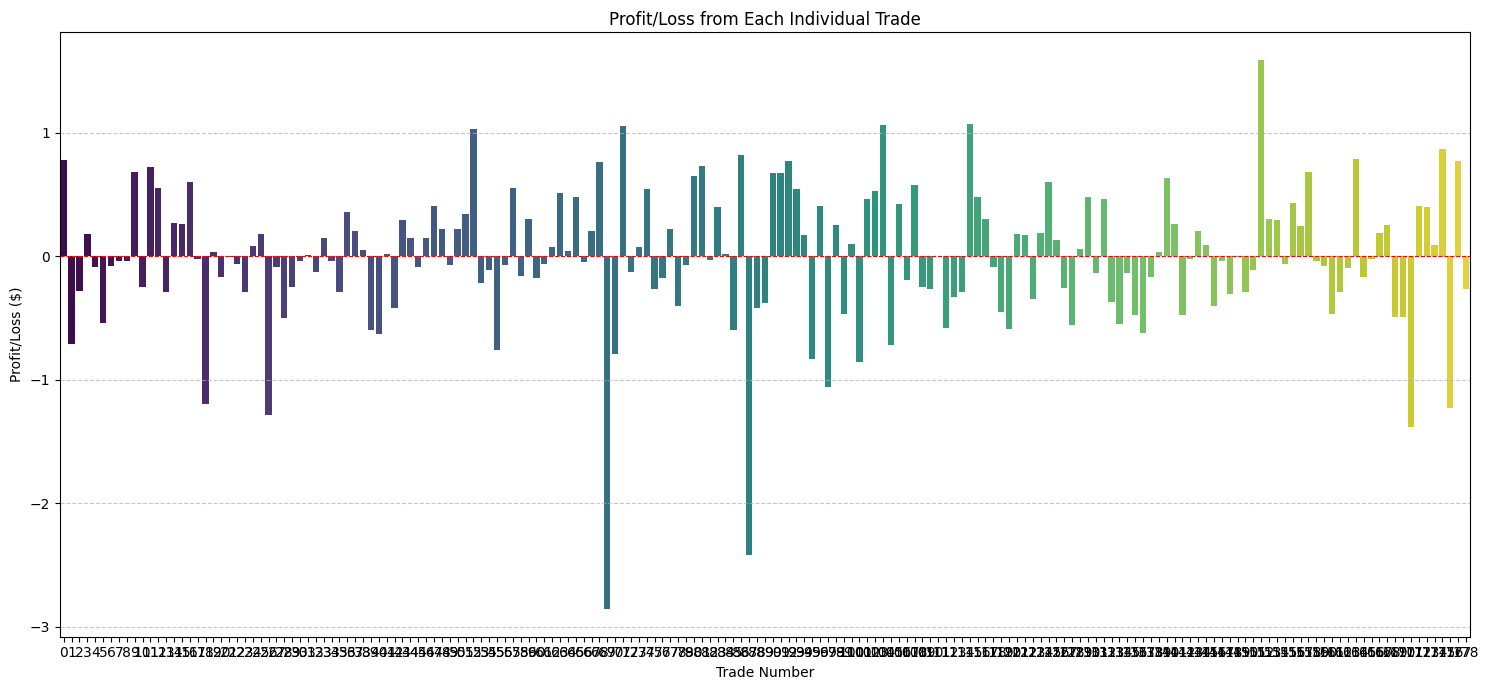

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the VZ_trades.csv file
trades_plot_df = pd.read_csv("VZ_trades.csv")

# Ensure 'Profit/Loss' is a numeric type for plotting
trades_plot_df['Profit/Loss'] = trades_plot_df['Profit/Loss'].replace({r'[$,]': ''}, regex=True).astype(float)

plt.figure(figsize=(15, 7))
sns.barplot(x=trades_plot_df.index, y='Profit/Loss', data=trades_plot_df, hue=trades_plot_df.index, legend=False, palette='viridis')
plt.title('Profit/Loss from Each Individual Trade')
plt.xlabel('Trade Number')
plt.ylabel('Profit/Loss ($)')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Add a horizontal line at y=0
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

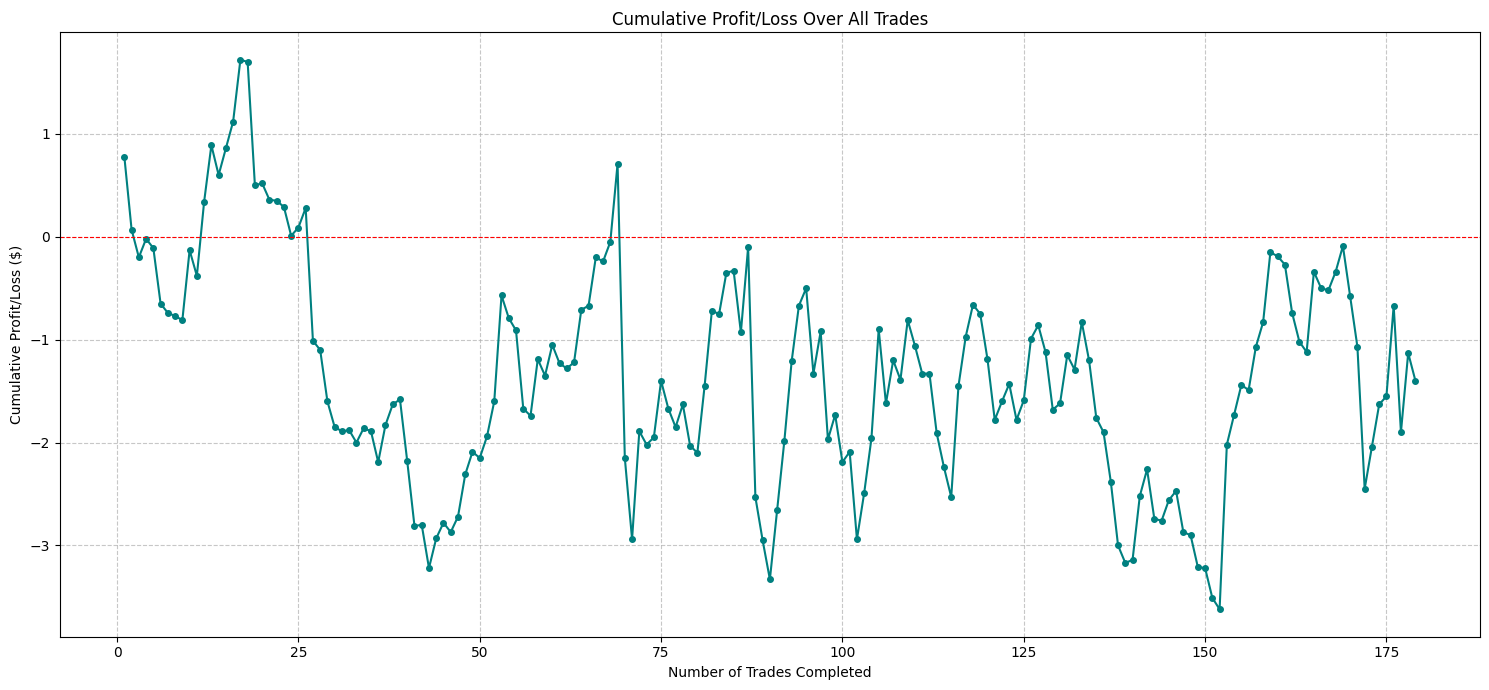

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Cumulative Profit' is numeric (it should be from the previous cell, but re-confirming)
# If this cell is run independently, it needs to convert from string format.
if isinstance(trades_df['Cumulative Profit'].iloc[0], str):
    trades_df['Cumulative Profit'] = trades_df['Cumulative Profit'].replace({r'[$,]': ''}, regex=True).astype(float)

plt.figure(figsize=(15, 7))
plt.plot(trades_df.index + 1, trades_df['Cumulative Profit'], marker='o', linestyle='-', color='teal', markersize=4)
plt.title('Cumulative Profit/Loss Over All Trades')
plt.xlabel('Number of Trades Completed')
plt.ylabel('Cumulative Profit/Loss ($)')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Show the breakeven point
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()